# visual-tcav — Tutorial

**visual-tcav** is a PyTorch package for concept-based attribution and saliency maps in Explainable AI.

Given a test image and a human concept (e.g. *stripes*), it produces:
- A **concept map** — a heatmap showing *where* a CNN detected that concept
- An **attribution score** — measuring *how much* the concept influenced the prediction

Based on: De Santis et al., [*Visual-TCAV: Concept-based Attribution and Saliency Maps for Post-hoc Explainability in Image Classification*](https://arxiv.org/abs/2411.05698), 2025.

---

**Prerequisites:** basic familiarity with PyTorch and convolutional neural networks.  
**Dataset:** concept images from [DTD (Describable Textures Dataset)](https://www.robots.ox.ac.uk/~vgg/data/dtd/).  
**Model:** ResNet50 pretrained on ImageNet.

## Installation

Choose the installation method that fits your workflow.

**pip** (recommended):
```bash
pip install visual-tcav
```

**conda**:
```bash
conda install -c conda-forge visual-tcav
```

**From source** (for development or to run this notebook directly):
```bash
git clone https://github.com/saracavallini01/visual-tcav.git
cd visual-tcav
pip install -e .
```

**Text-to-Concept extension** (optional, requires CLIP):
```bash
pip install visual-tcav[text-to-concept]
pip install git+https://github.com/openai/CLIP.git
```

---

## 1. Getting started

The minimal working example. Run this first to verify your installation is correct.

In [20]:
from visual_tcav import available_layers, LocalVisualTCAV

# Before creating an explainer, inspect what layers are available
available_layers("resnet50")

+----------------------+
|   Model: resnet50    |
+------------+---------+
| N. classes |  Layers |
+------------+---------+
|    1000    |  conv1  |
|            |   bn1   |
|            |   relu  |
|            | maxpool |
|            |  layer1 |
|            |  layer2 |
|            |  layer3 |
|            |  layer4 |
+------------+---------+


Test image loaded: zebra.jpg
Concepts set: ['striped']
Layers set: ['layer4']

Running LocalVisualTCAV explanation...
  Image:    zebra.jpg
  Layers:   ['layer4']
  Concepts: ['striped']
  Classes:  ['zebra', 'hartebeest', 'impala']

Layer: layer4
  Loading random activations from cache.
  Concept: striped
  Loading CAV from cache: striped @ layer4
    zebra: 2.2250
    hartebeest: 0.1921
    impala: 0.0681

Explanation complete. Call plot() to visualize results.


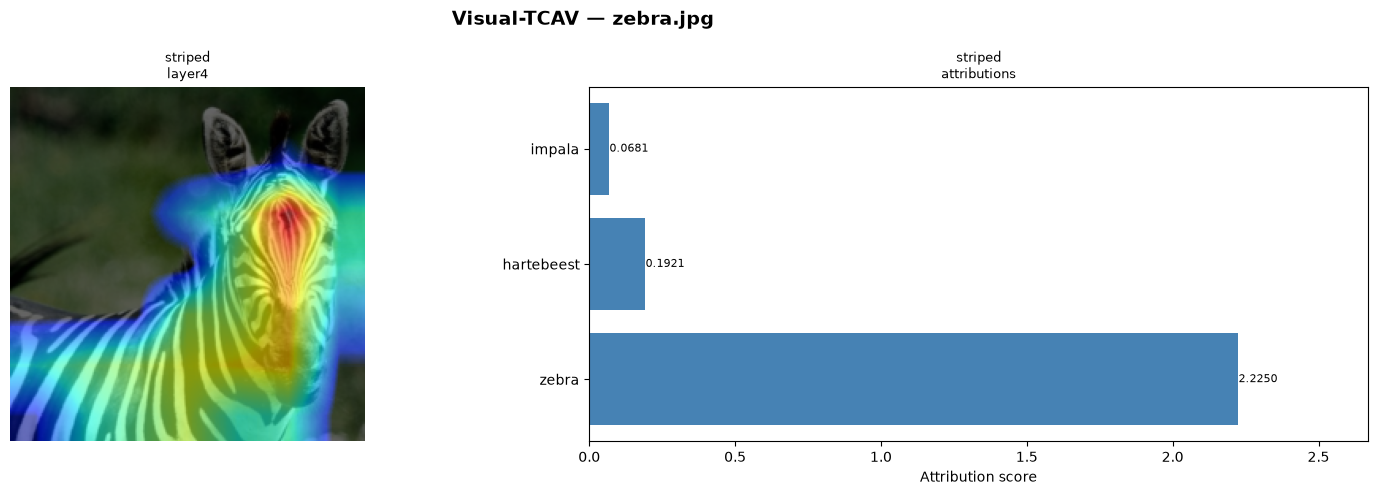

In [21]:
import os

# All paths are configurable — set them to wherever your files are
CONCEPT_DIR     = "./data/concept_images"
RANDOM_DIR      = "./data/concept_images/random"
TEST_IMAGES_DIR = "./data/test_images"
CACHE_DIR       = "./data/.cache"

# Minimal example — five lines to produce a Visual-TCAV explanation
tcav = LocalVisualTCAV(
    model="resnet50",
    test_image_path=os.path.join(TEST_IMAGES_DIR, "zebra.jpg"),
    concept_names=["striped"],
    concept_base_dir=CONCEPT_DIR,
    random_dir=RANDOM_DIR,
    layer_names=["layer4"],
    cache_dir=CACHE_DIR,
)
tcav.explain()
tcav.plot()

---

## 2. Understanding the output

The plot above contains two components.

**Concept map (left):**  
A heatmap overlaid on the original image. Red and yellow areas indicate where ResNet50 detected the concept *striped*. Black areas indicate the concept is absent. The map is computed from the feature maps at `layer4` (spatial resolution 7×7), upscaled to the image size (224×224) using bilinear interpolation.

**Attribution score (right):**  
A scalar value per predicted class. It measures how much the concept *striped* contributed to each class prediction. Scores are not percentages — what matters is their relative magnitude across concepts. A much higher score for *striped* than *dotted* on a zebra image confirms that the model uses stripes as a discriminative feature for classifying zebras.

**Supported models for string loading:**  
`resnet18`, `resnet50`, `resnet101`, `vgg16`, `vgg19`

---

## 3. LocalVisualTCAV — full walkthrough

This section demonstrates all LocalVisualTCAV features step by step.

### 3.1 Loading the model

Two standard ways to provide a model. Both produce identical results.

In [22]:
import torch
import torchvision.models as models

print(f"PyTorch: {torch.__version__}")
print(f"Device: {'GPU' if torch.cuda.is_available() else 'CPU'}")

# Option A — model name string (simplest)
# The package loads the model with default ImageNet weights automatically
tcav_a = LocalVisualTCAV(
    model="resnet50",
    test_image_path=os.path.join(TEST_IMAGES_DIR, "zebra.jpg"),
    concept_names=["striped", "dotted"],
    concept_base_dir=CONCEPT_DIR,
    random_dir=RANDOM_DIR,
    layer_names=["layer4"],
    cache_dir=CACHE_DIR,
)
print("Option A loaded:", tcav_a.model_wrapper.model_name)

PyTorch: 2.13.0+cpu
Device: CPU
Test image loaded: zebra.jpg
Concepts set: ['striped', 'dotted']
Layers set: ['layer4']
Option A loaded: resnet50


In [23]:
# Option B — nn.Module directly
# Use this for fine-tuned models, custom weights, or non-standard architectures
# Set model_name to enable auto-loading of labels for known models
my_resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
available_layers(my_resnet, model_name="resnet50")

+----------------------+
|   Model: resnet50    |
+------------+---------+
| N. classes |  Layers |
+------------+---------+
|    1000    |  conv1  |
|            |   bn1   |
|            |   relu  |
|            | maxpool |
|            |  layer1 |
|            |  layer2 |
|            |  layer3 |
|            |  layer4 |
+------------+---------+


In [24]:
tcav_b = LocalVisualTCAV(
    model=my_resnet,
    model_name="resnet50",
    test_image_path=os.path.join(TEST_IMAGES_DIR, "zebra.jpg"),
    concept_names=["striped", "dotted"],
    concept_base_dir=CONCEPT_DIR,
    random_dir=RANDOM_DIR,
    layer_names=["layer4"],
    cache_dir=CACHE_DIR,
)
print("Option B loaded:", tcav_b.model_wrapper.model_name)

Test image loaded: zebra.jpg
Concepts set: ['striped', 'dotted']
Layers set: ['layer4']
Option B loaded: resnet50


### 3.2 Predict

`predict()` runs the image through the model and returns the top predicted classes.  
Calling it explicitly is **optional** — `explain()` calls it automatically if you skip it.

In [25]:
predictions = tcav_a.predict()
predictions.info(num_of_classes=5)

+-------------------------------------+
|           Model: resnet50           |
+-----------+------------+------------+
|   Image   | Class name | Confidence |
+-----------+------------+------------+
| zebra.jpg |   zebra    |   0.5591   |
|           | hartebeest |   0.0015   |
|           |   impala   |   0.0012   |
+-----------+------------+------------+


Image,Class name,Confidence
zebra.jpg,zebra,0.5591
,hartebeest,0.0015
,impala,0.0012


### 3.3 Explain without calling predict() first

`explain()` calls `predict()` automatically if it has not been called yet.  
This means you can always go directly from construction to explanation.


Running LocalVisualTCAV explanation...
  Image:    zebra.jpg
  Layers:   ['layer4']
  Concepts: ['striped', 'dotted']
  Classes:  ['zebra', 'hartebeest', 'impala']

Layer: layer4
  Loading random activations from cache.
  Concept: striped
  Loading CAV from cache: striped @ layer4
    zebra: 2.2250
    hartebeest: 0.1921
    impala: 0.0681
  Concept: dotted
  Loading CAV from cache: dotted @ layer4
    zebra: -0.0010
    hartebeest: -0.0001
    impala: 0.0000

Explanation complete. Call plot() to visualize results.


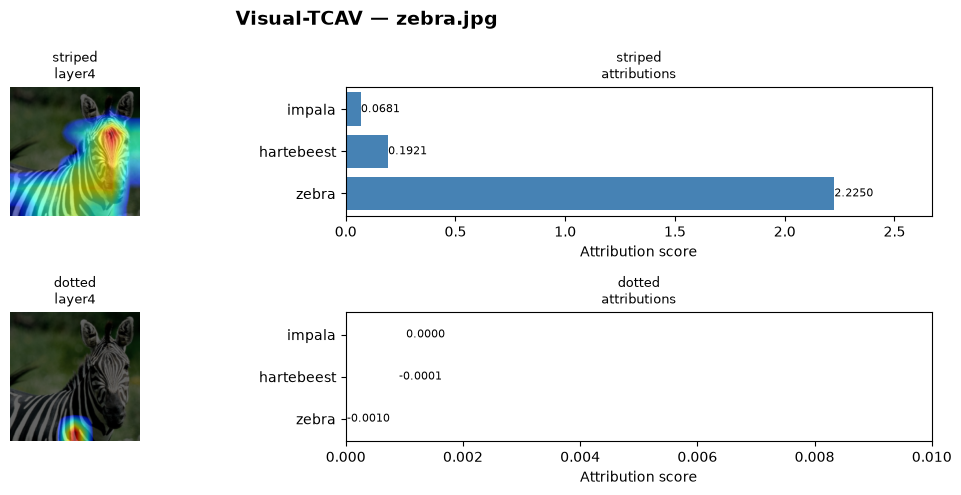

In [26]:
# No predict() call — explain() handles it
tcav_b.explain()
tcav_b.plot(figsize=(12, 5))

### 3.4 Analyzing multiple concepts

Test image loaded: zebra.jpg
Concepts set: ['striped', 'dotted', 'zigzagged', 'chequered']
Layers set: ['layer4']

Running LocalVisualTCAV explanation...
  Image:    zebra.jpg
  Layers:   ['layer4']
  Concepts: ['striped', 'dotted', 'zigzagged', 'chequered']
  Classes:  ['zebra', 'hartebeest', 'impala']

Layer: layer4
  Loading random activations from cache.
  Concept: striped
  Loading CAV from cache: striped @ layer4
    zebra: 2.2250
    hartebeest: 0.1921
    impala: 0.0681
  Concept: dotted
  Loading CAV from cache: dotted @ layer4
    zebra: -0.0010
    hartebeest: -0.0001
    impala: 0.0000
  Concept: zigzagged
  Computing CAV: 'zigzagged' @ 'layer4'...
    zebra: -0.0015
    hartebeest: -0.0002
    impala: -0.0000
  Concept: chequered
  Computing CAV: 'chequered' @ 'layer4'...
    zebra: 0.0002
    hartebeest: 0.0000
    impala: 0.0000

Explanation complete. Call plot() to visualize results.


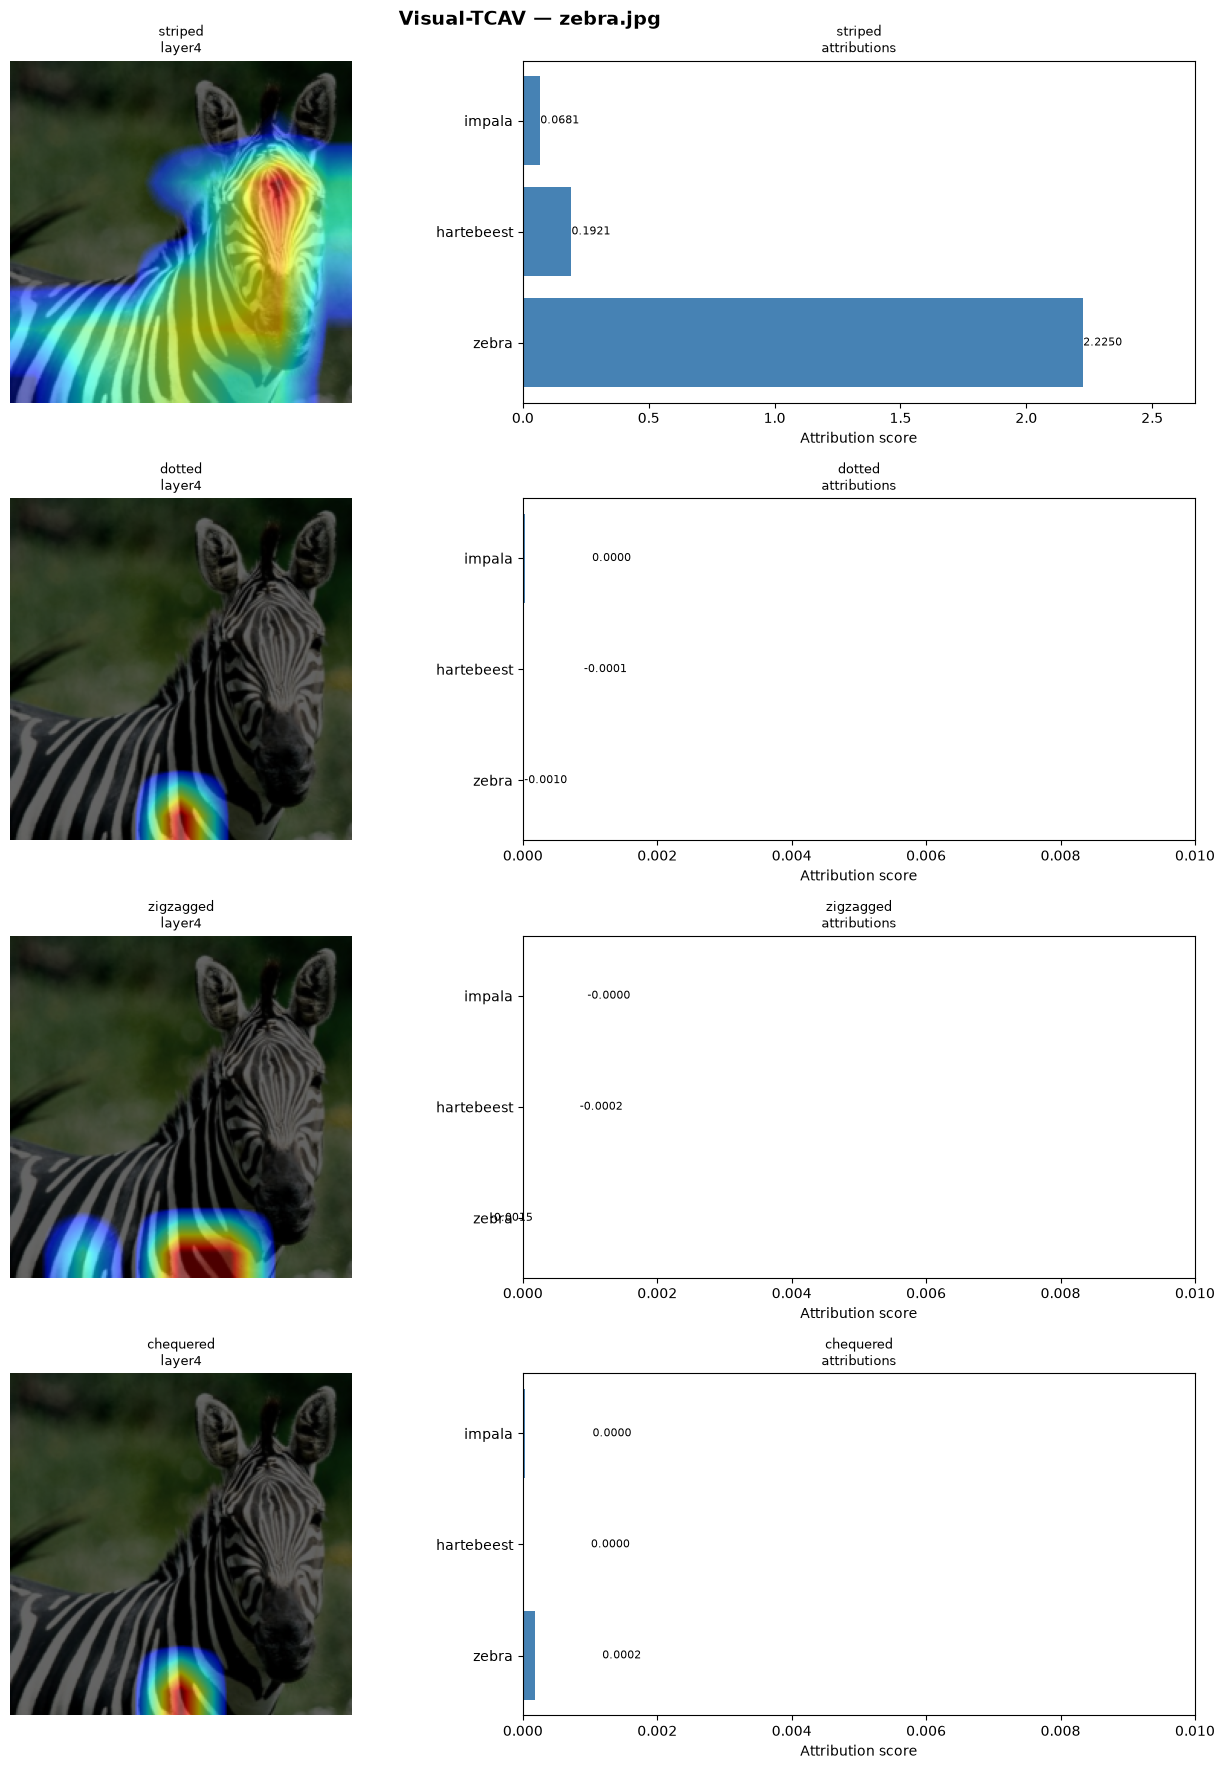

In [27]:
tcav_multi_concept = LocalVisualTCAV(
    model="resnet50",
    test_image_path=os.path.join(TEST_IMAGES_DIR, "zebra.jpg"),
    concept_names=["striped", "dotted", "zigzagged", "chequered"],
    concept_base_dir=CONCEPT_DIR,
    random_dir=RANDOM_DIR,
    layer_names=["layer4"],
    n_classes=3,
    cache_dir=CACHE_DIR,
)
tcav_multi_concept.explain()
tcav_multi_concept.plot(figsize=(14, 18))

---

## 4. Multiple layers — how concept detection evolves with depth

Analyzing the same concept at different layers reveals how detection changes along the network.  
Early layers capture low-level textures; deeper layers capture higher-level patterns.

Use `available_layers("resnet50")` to see all layer names.

Test image loaded: zebra.jpg
Concepts set: ['striped']
Layers set: ['layer2', 'layer3', 'layer4']

Running LocalVisualTCAV explanation...
  Image:    zebra.jpg
  Layers:   ['layer2', 'layer3', 'layer4']
  Concepts: ['striped']
  Classes:  ['zebra', 'hartebeest', 'impala']

Layer: layer2
  Computing random activations at 'layer2'...
  Concept: striped
  Computing CAV: 'striped' @ 'layer2'...
    zebra: 0.6178
    hartebeest: 0.4864
    impala: 0.3524
Layer: layer3
  Computing random activations at 'layer3'...
  Concept: striped
  Computing CAV: 'striped' @ 'layer3'...
    zebra: 0.4901
    hartebeest: 0.0491
    impala: 0.0499
Layer: layer4
  Loading random activations from cache.
  Concept: striped
  Loading CAV from cache: striped @ layer4
    zebra: 2.2250
    hartebeest: 0.1921
    impala: 0.0681

Explanation complete. Call plot() to visualize results.


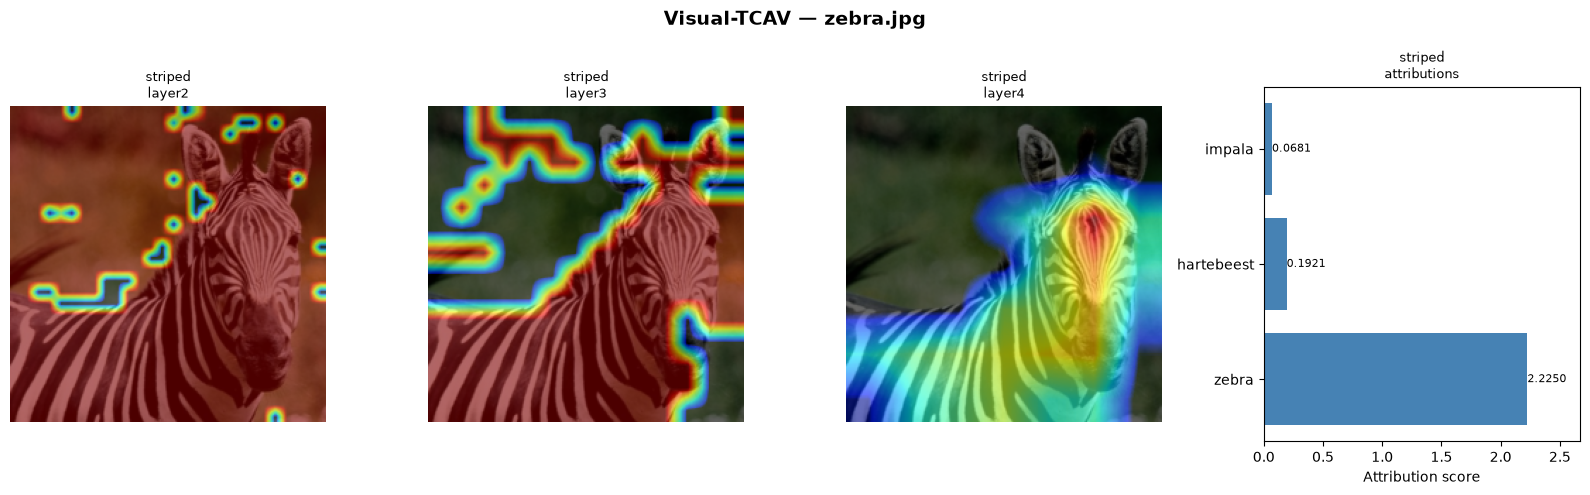

In [28]:
tcav_layers = LocalVisualTCAV(
    model="resnet50",
    test_image_path=os.path.join(TEST_IMAGES_DIR, "zebra.jpg"),
    concept_names=["striped"],
    concept_base_dir=CONCEPT_DIR,
    random_dir=RANDOM_DIR,
    layer_names=["layer2", "layer3", "layer4"],
    cache_dir=CACHE_DIR,
)
tcav_layers.explain()
tcav_layers.plot(figsize=(16, 5))

The concept map becomes more spatially precise in deeper layers: `layer2` highlights broad regions, while `layer4` focuses on the specific stripes on the zebra's body.

---

## 5. GlobalVisualTCAV — explaining a class across many images

`GlobalVisualTCAV` runs the pipeline on a folder of images and produces statistical summaries.  
It answers: **does this concept consistently influence predictions for this class?**

Results include:
- **Mean** — average attribution across all images
- **Std** — variability across images
- **95% CI** — reliability of the estimate

A narrow confidence interval that does not include zero means the concept reliably influences predictions.

In [29]:
from visual_tcav import GlobalVisualTCAV

tcav_global = GlobalVisualTCAV(
    model="resnet50",
    test_images_dir=os.path.join(TEST_IMAGES_DIR, "zebra"),
    concept_names=["striped", "dotted", "zigzagged"],
    concept_base_dir=CONCEPT_DIR,
    random_dir=RANDOM_DIR,
    layer_names=["layer4"],
    n_classes=3,
    max_test_images=50,
    cache_dir=CACHE_DIR,
)
tcav_global.explain()

Test images loaded: 50 from ./data/test_images\zebra
Concepts set: ['striped', 'dotted', 'zigzagged']
Layers set: ['layer4']

Running GlobalVisualTCAV explanation...
  Images:   50 test images
  Layers:   ['layer4']
  Concepts: ['striped', 'dotted', 'zigzagged']

Phase 1: Computing CAVs...
  Loading random activations from cache.
  Loading CAV from cache: striped @ layer4
  Loading CAV from cache: dotted @ layer4
  Loading CAV from cache: zigzagged @ layer4

Phase 2: Processing 50 images...


Images: 100%|██████████| 50/50 [00:35<00:00,  1.42it/s]


Phase 3: Computing statistics...

Explanation complete. Call statsInfo() or plot() for results.


In [30]:
# Statistical summary table
tcav_global.statsInfo()

+---------------------------------------------------------------------+
|                     GlobalVisualTCAV — resnet50                     |
+-----------+--------+-----------+--------+--------+------------------+
| Concept   | Layer  | Class     | Mean   | Std    | 95% CI           |
+-----------+--------+-----------+--------+--------+------------------+
| striped   | layer4 | zebra     | 2.0787 | 0.6675 | [1.8899, 2.2675] |
| striped   | layer4 | velvet    | 0.1356 | 0.1804 | [0.0846, 0.1867] |
| striped   | layer4 | drumstick | 0.1026 | 0.0944 | [0.0759, 0.1293] |
| dotted    | layer4 | zebra     | 0.0056 | 0.0469 | [0.0000, 0.0188] |
| dotted    | layer4 | velvet    | 0.0034 | 0.0152 | [0.0000, 0.0077] |
| dotted    | layer4 | drumstick | 0.0017 | 0.0051 | [0.0002, 0.0031] |
| zigzagged | layer4 | zebra     | 0.0067 | 0.0444 | [0.0000, 0.0193] |
| zigzagged | layer4 | velvet    | 0.0061 | 0.0250 | [0.0000, 0.0132] |
| zigzagged | layer4 | drumstick | 0.0033 | 0.0150 | [0.0000, 0.

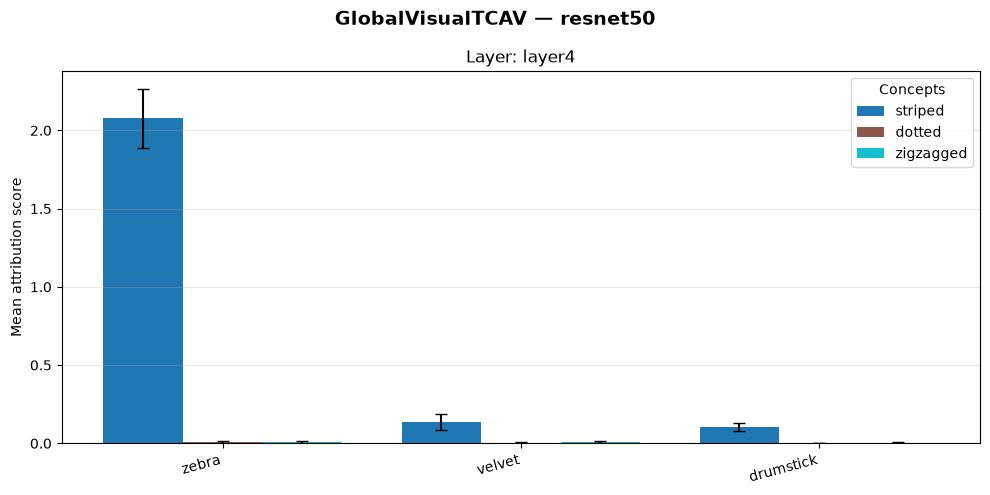

In [31]:
# Bar chart with confidence intervals
tcav_global.plot(figsize=(10, 5))

---

## 6. Cache management

visual-tcav caches two types of results to disk:
- **Random activations** — CNN activations of random images at each layer. Depend only on model and layer, not on the test image or concepts.
- **CAVs** — Concept Activation Vectors for each (concept, layer) pair. Depend on concept images, model, and layer.

Caching avoids redundant computation when experimenting with different test images but the same model and concepts.

In [32]:
tcav_cache = LocalVisualTCAV(
    model="resnet50",
    test_image_path=os.path.join(TEST_IMAGES_DIR, "zebra.jpg"),
    concept_names=["striped"],
    concept_base_dir=CONCEPT_DIR,
    random_dir=RANDOM_DIR,
    layer_names=["layer4"],
    cache_dir=CACHE_DIR,
)

# Default: use cache if available (fast on subsequent runs)
tcav_cache.explain()

# Force full recomputation — use when concept images or model change
tcav_cache.explain(force_recompute=True)

# Clear all cached files
tcav_cache.clear_cache()
print(f"Cache cleared: {CACHE_DIR}")

Test image loaded: zebra.jpg
Concepts set: ['striped']
Layers set: ['layer4']

Running LocalVisualTCAV explanation...
  Image:    zebra.jpg
  Layers:   ['layer4']
  Concepts: ['striped']
  Classes:  ['zebra', 'hartebeest', 'impala']

Layer: layer4
  Loading random activations from cache.
  Concept: striped
  Loading CAV from cache: striped @ layer4
    zebra: 2.2250
    hartebeest: 0.1921
    impala: 0.0681

Explanation complete. Call plot() to visualize results.

Running LocalVisualTCAV explanation...
  Image:    zebra.jpg
  Layers:   ['layer4']
  Concepts: ['striped']
  Classes:  ['zebra', 'hartebeest', 'impala']

Layer: layer4
  Computing random activations at 'layer4'...
  Concept: striped
  Computing CAV: 'striped' @ 'layer4'...
    zebra: 4.1016
    hartebeest: 0.3533
    impala: 0.1250

Explanation complete. Call plot() to visualize results.
Cache cleared: ./data/.cache
Cache cleared: ./data/.cache


In [33]:
# Disable caching entirely — useful on clusters with disk quotas
tcav_no_cache = LocalVisualTCAV(
    model="resnet50",
    test_image_path=os.path.join(TEST_IMAGES_DIR, "zebra.jpg"),
    concept_names=["striped"],
    concept_base_dir=CONCEPT_DIR,
    random_dir=RANDOM_DIR,
    layer_names=["layer4"],
    cache_dir=None,  # caching disabled — nothing written to disk
)
tcav_no_cache.explain()

Test image loaded: zebra.jpg
Concepts set: ['striped']
Layers set: ['layer4']

Running LocalVisualTCAV explanation...
  Image:    zebra.jpg
  Layers:   ['layer4']
  Concepts: ['striped']
  Classes:  ['zebra', 'hartebeest', 'impala']

Layer: layer4
  Computing random activations at 'layer4'...
  Concept: striped
  Computing CAV: 'striped' @ 'layer4'...
    zebra: 4.1016
    hartebeest: 0.3533
    impala: 0.1250

Explanation complete. Call plot() to visualize results.


---

## 7. Custom CAV computation function

By default, the CAV direction is computed as the difference between the mean concept activation and the mean random activation (centroid difference).  

The `cav_fn` parameter follows the **Strategy Pattern**: it lets you replace the default algorithm with any custom function, without modifying the package source code.

The function must accept two tensors of shape `[N, C]` and return a `Cav` object.

Test image loaded: zebra.jpg
Concepts set: ['striped', 'dotted']
Layers set: ['layer4']

Running LocalVisualTCAV explanation...
  Image:    zebra.jpg
  Layers:   ['layer4']
  Concepts: ['striped', 'dotted']
  Classes:  ['zebra', 'hartebeest', 'impala']

Layer: layer4
  Computing random activations at 'layer4'...
  Concept: striped
  Computing CAV: 'striped' @ 'layer4'...
    zebra: 2.2250
    hartebeest: 0.1921
    impala: 0.0681
  Concept: dotted
  Computing CAV: 'dotted' @ 'layer4'...
    zebra: -0.0010
    hartebeest: -0.0001
    impala: 0.0000

Explanation complete. Call plot() to visualize results.


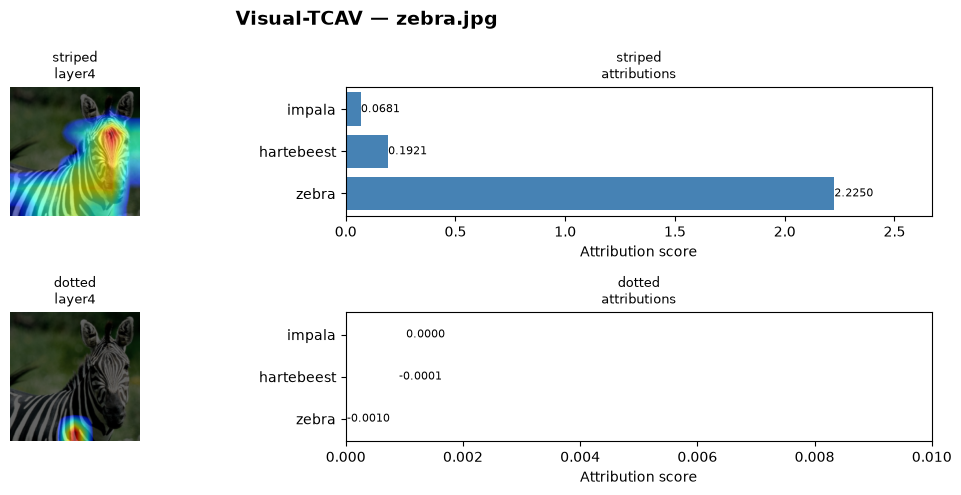

In [34]:
from visual_tcav import Cav
import torch

# Example: normalized centroid difference
# Normalizing to unit length makes attribution scores comparable
# across concepts with different activation magnitudes
def normalized_centroid_cav(
    concept_features: torch.Tensor,
    random_features: torch.Tensor,
) -> Cav:
    direction = (
        torch.mean(concept_features, dim=0)
        - torch.mean(random_features, dim=0)
    )
    direction = direction / (torch.norm(direction) + 1e-10)
    return Cav(direction=direction)


tcav_custom = LocalVisualTCAV(
    model="resnet50",
    test_image_path=os.path.join(TEST_IMAGES_DIR, "zebra.jpg"),
    concept_names=["striped", "dotted"],
    concept_base_dir=CONCEPT_DIR,
    random_dir=RANDOM_DIR,
    layer_names=["layer4"],
    cache_dir=CACHE_DIR,
    cav_fn=normalized_centroid_cav,
)

# force_recompute=True because the CAV function changed
tcav_custom.explain(force_recompute=True)
tcav_custom.plot(figsize=(12, 5))

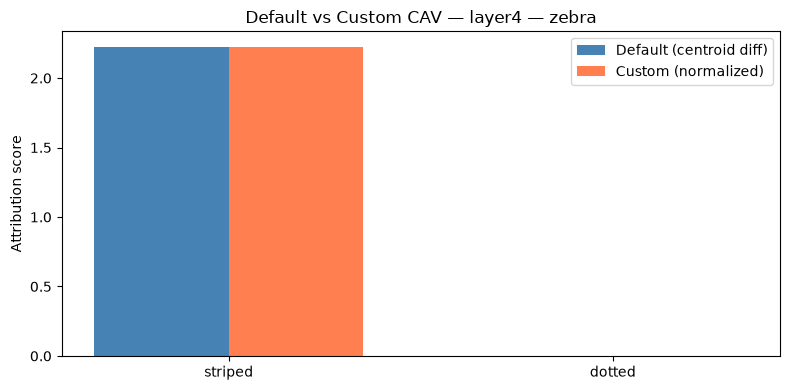

In [35]:
import numpy as np
import matplotlib.pyplot as plt

# Compare default vs custom CAV attribution scores
concepts = ["striped", "dotted"]
layer = "layer4"
top_class = tcav_multi_concept.target_classes[0]

default_scores = [
    tcav_multi_concept.computations[layer][c].attributions.get(
        top_class, torch.tensor(0.0)
    ).item()
    for c in concepts
]
custom_scores = [
    tcav_custom.computations[layer][c].attributions.get(
        top_class, torch.tensor(0.0)
    ).item()
    for c in concepts
]

x = np.arange(len(concepts))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - width/2, default_scores, width,
       label="Default (centroid diff)", color="steelblue")
ax.bar(x + width/2, custom_scores, width,
       label="Custom (normalized)", color="coral")
ax.set_xticks(x)
ax.set_xticklabels(concepts)
ax.set_ylabel("Attribution score")
ax.set_title(
    f"Default vs Custom CAV — layer4 — "
    f"{tcav_multi_concept.model_wrapper.id_to_label(top_class)}"
)
ax.legend()
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

---

## 8. Saving results to disk

Both `LocalVisualTCAV.plot()` and `GlobalVisualTCAV.plot()` accept a `save_path`
parameter to save figures instead of displaying them interactively.
Useful for batch processing and generating publication-ready figures.

Plot saved to: ./results/zebra_local_explanation.png
Plot saved to: ./results/zebra_global_explanation.png
Saved to ./results/


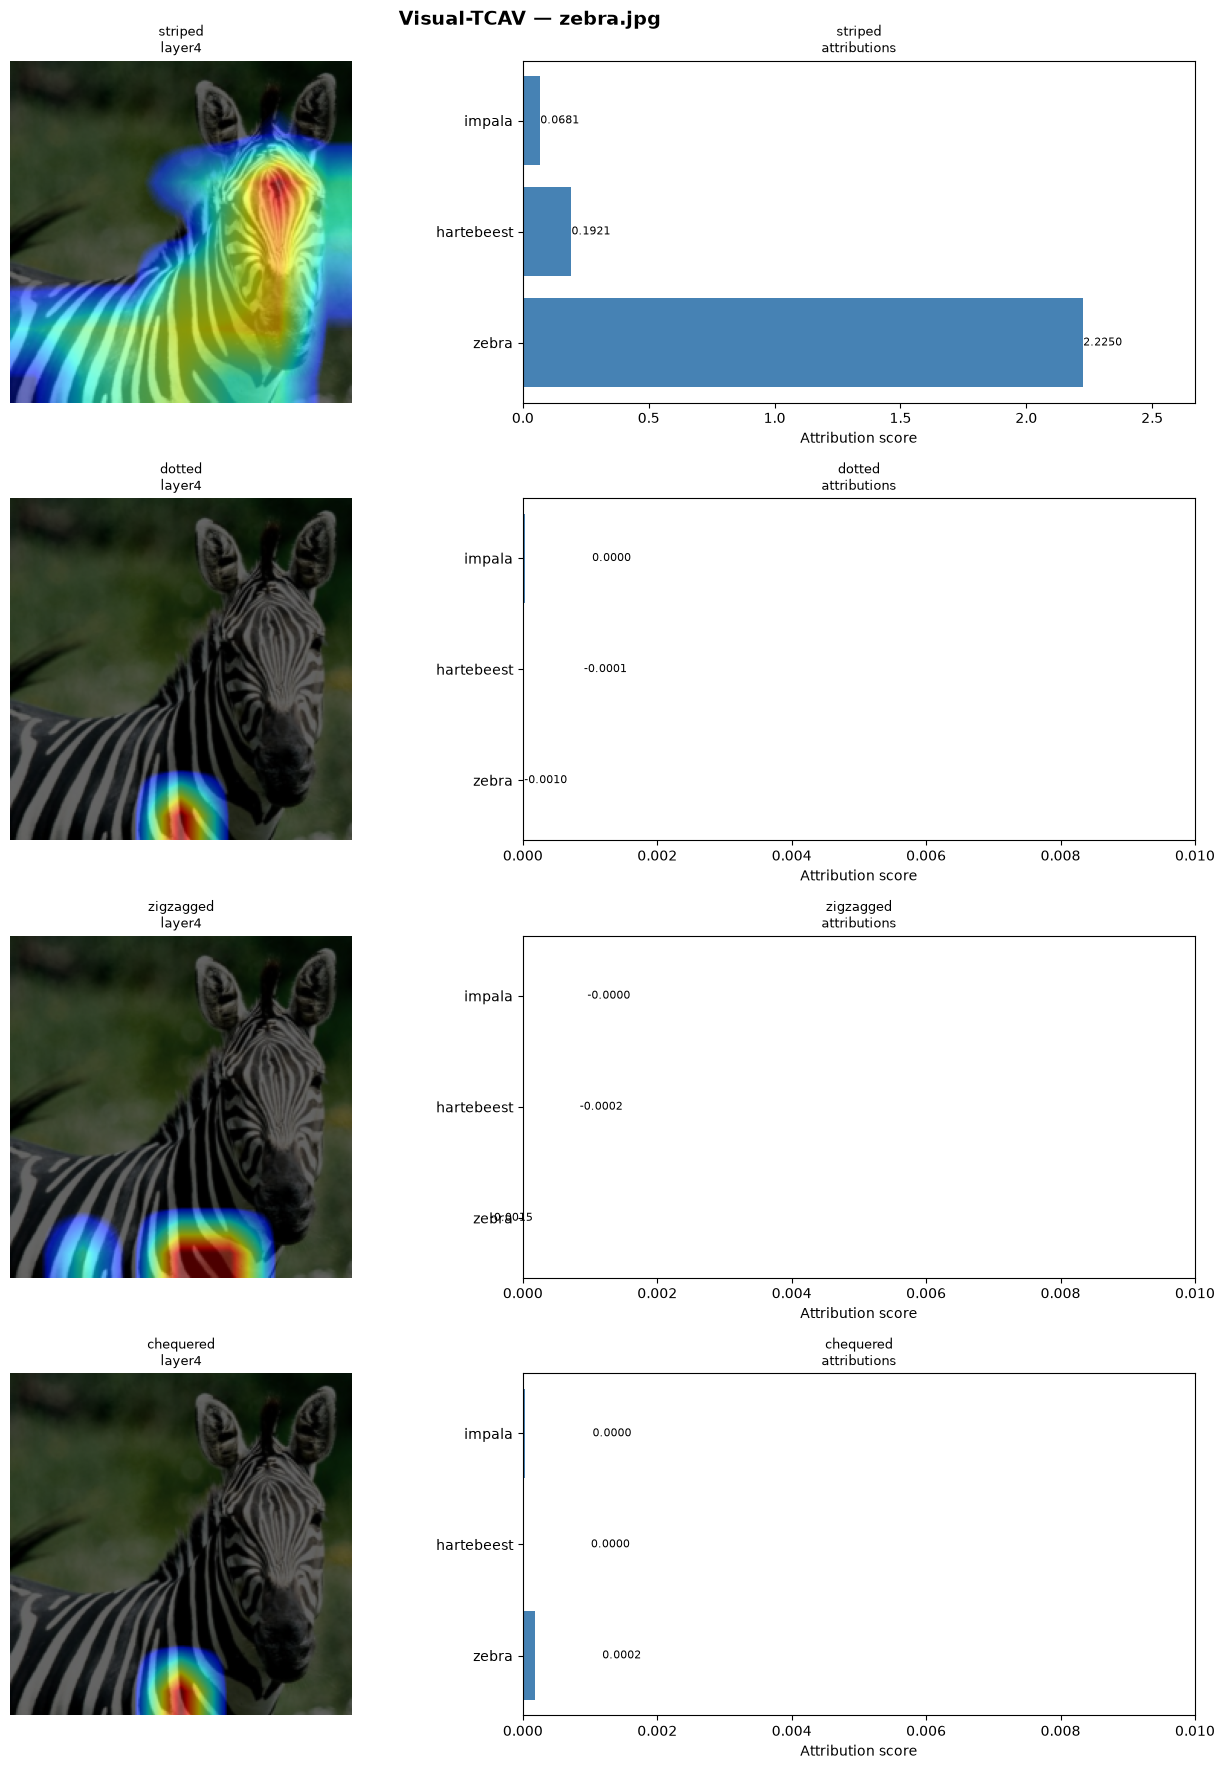

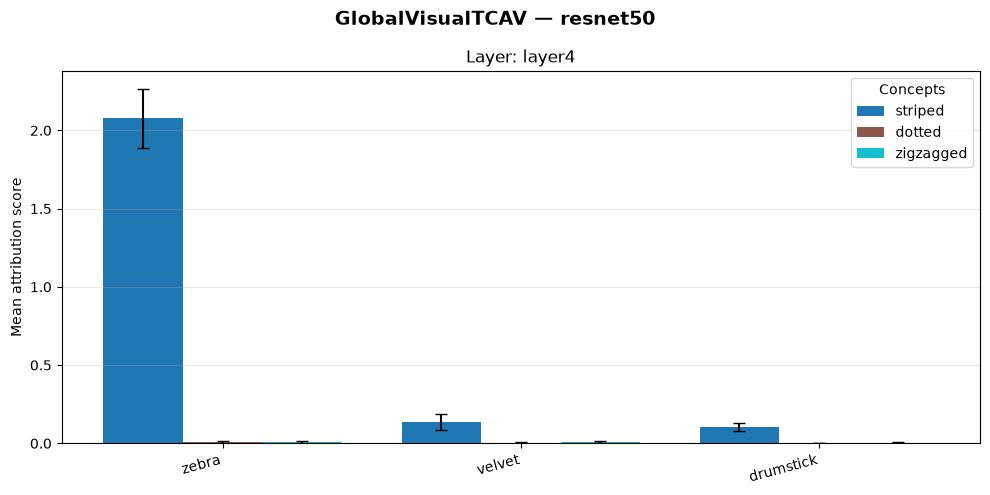

In [36]:
os.makedirs("./results", exist_ok=True)

tcav_multi_concept.plot(
    figsize=(14, 18),
    save_path="./results/zebra_local_explanation.png",
)
tcav_global.plot(
    figsize=(10, 5),
    save_path="./results/zebra_global_explanation.png",
)
print("Saved to ./results/")

---

## 9. Command-line interface

visual-tcav includes a CLI built with [click](https://click.palletsprojects.com),
useful for running explanations on remote servers and supercomputing clusters
without writing Python code.

After `pip install visual-tcav`, the following commands are available:

```bash
# Show available layers for a model
visual-tcav info --model resnet50

# Local explanation (single image)
visual-tcav local \
    --model resnet50 \
    --image ./data/test_images/zebra.jpg \
    --concepts striped dotted \
    --concept-dir ./data/concept_images \
    --layers layer4 \
    --output ./results

# Global explanation (folder of images)
visual-tcav global \
    --model resnet50 \
    --images-dir ./data/test_images/zebra \
    --concepts striped dotted \
    --concept-dir ./data/concept_images \
    --layers layer4 \
    --output ./results

# Force recomputation (ignore cache)
visual-tcav local ... --no-cache
```

In [37]:
# Verify the CLI is installed
import subprocess
result = subprocess.run(["visual-tcav", "--help"], capture_output=True, text=True)
print(result.stdout)

Usage: visual-tcav [OPTIONS] COMMAND [ARGS]...

  visual-tcav: Concept-based Attribution and Saliency Maps for XAI in PyTorch.

  Run Visual-TCAV explanations from the command line. Use --help on any
  subcommand for details.

Options:
  --version  Show the version and exit.
  --help     Show this message and exit.

Commands:
  global  Explain a class of images using GlobalVisualTCAV.
  info    Show available CNN layers for a model.
  local   Explain a single image using LocalVisualTCAV.



---

## 10. Text-to-Concept (optional — requires CLIP)

The Text-to-Concept extension generates CAVs from plain text descriptions
instead of concept images, using CLIP and a trained Linear Aligner.

Install:
```bash
pip install visual-tcav[text-to-concept]
pip install git+https://github.com/openai/CLIP.git
```

Based on:
- Di Santi, D., *Text-to-Concept Extension for Visual-TCAV*, Master's Thesis, Politecnico di Milano, 2025.
- Moayeri et al., *Text-To-Concept (and Back) via Cross-Model Alignment*, ICML 2023.

In [38]:
try:
    from visual_tcav import TextToConcept

    t2c = TextToConcept(model_wrapper=tcav_multi_concept.model_wrapper)
    t2c.load_aligner("./aligners/resnet50_layer4.pt")

    cav_from_text = t2c.get_cav_from_text("stripes", layer_name="layer4")
    print(f"CAV direction shape: {cav_from_text.direction.shape}")

except ImportError:
    print("CLIP not installed.")
    print("Run: pip install visual-tcav[text-to-concept]")
    print("     pip install git+https://github.com/openai/CLIP.git")
except FileNotFoundError:
    print("Linear Aligner not found.")
    print("Train it first using train_aligners.py")

Linear Aligner not found.
Train it first using train_aligners.py


---

## 11. API quick reference

| Feature | API |
|---|---|
| Inspect layers | `available_layers("resnet50")` |
| Inspect nn.Module layers | `available_layers(my_model, model_name="resnet50")` |
| Model as string | `LocalVisualTCAV(model="resnet50", ...)` |
| Model as nn.Module | `LocalVisualTCAV(model=my_model, model_name="resnet50", ...)` |
| Skip predict() | `explain()` calls it automatically |
| Use cache (default) | `tcav.explain()` |
| Force recompute | `tcav.explain(force_recompute=True)` |
| Clear cache | `tcav.clear_cache()` |
| Disable cache | `LocalVisualTCAV(..., cache_dir=None)` |
| Multiple layers | `layer_names=["layer2", "layer3", "layer4"]` |
| Multiple concepts | `concept_names=["striped", "dotted", "zigzagged"]` |
| Custom CAV | `LocalVisualTCAV(cav_fn=my_function, ...)` |
| Global explanation | `GlobalVisualTCAV(test_images_dir=..., ...)` |
| Statistics | `tcav.statsInfo()` |
| Save figure | `plot(save_path="./output.png")` |
| CLI info | `visual-tcav info --model resnet50` |
| CLI local | `visual-tcav local --model resnet50 --image ... --concepts ... --layers ...` |
| CLI global | `visual-tcav global --model resnet50 --images-dir ... --concepts ... --layers ...` |
| Text-to-Concept | `TextToConcept` + `load_aligner()` + `get_cav_from_text()` |

---

**GitHub:** https://github.com/saracavallini01/visual-tcav  
**PyPI:** `pip install visual-tcav`  
**Paper:** https://arxiv.org/abs/2411.05698